# Exploring Chant Sources with PyCantus

This notebook introduces the **PyCantus** library for working with medieval chant data from the [Cantus Database](https://cantusdatabase.org/). We will:

1. Load a `Corpus` from local CSV files (or remote URLs) using the `Corpus` class
2. Inspect `Source` objects with `vars()` and convert them to Pandas DataFrames using list comprehension
3. Clean and enrich source data — extracting country codes from sigla and coercing century values — then group and visualize sources by century, country, and cursus with Plotly
4. Explore `Chant` objects: examine individual fields, filter by criteria with `for` loops and conditionals, and build a chant DataFrame
5. Map genre and office codes to readable names using Python dictionaries, then chart chant distributions by mode, office, and feast
6. Work with encoded melodies: filter for chants with Volpiano, inspect `Melody` objects, apply cleaning methods (`normalize_volpiano`, `clean_volpiano`, etc.), and render notation as SVG using Verovio


Learn more about Pycantus at: `https://github.com/dact-chant/PyCantus/tree/main`



**Background: The Cantus Data Model**

| Term | Meaning |
|---|---|
| **Source** | A physical manuscript or printed book containing chants |
| **Chant** | One occurrence of a chant in a source, with text and (optionally) a melody |
| **Corpus** | A collection of sources and chants, loaded from CSV |
| **Volpiano** | A text-based encoding of a chant melody |
| **Genre** | The liturgical type of a chant (A = Antiphon, R = Responsory, etc.) |



## 1. Installation & Imports

In [1]:
import pandas as pd

import os

import plotly.express as px
import re
import numpy as np

import copy

from pycantus.models import Corpus

import verovio
from IPython.display import SVG, display

# Quick sanity check
from pycantus import hello_pycantus
hello_pycantus()


    *********************************************
    *                                           *
    *           Welcome to PyCantus!            *
    *                                           *
    *    A Python library designed to enhance   *
    *    accessibility of Gregorian chants for  *
    *    both coders and non-coders.            *
    *                                           *
    *********************************************
    



## 2. Loading the Sample Corpus

A **Corpus** is loaded from two CSV files:
- `chants.csv` — one row per chant occurrence
- `sources.csv` — one row per manuscript source

Note that you can find these CSV files in the `cantus_data` folder of this project.  Load them with the code in the next cell.

Alternatively, you can load them directly from the URLs where they are hosted on GitHub.  Set the following variables to the URLs:

```python
CHANTS_URL  = 'https://raw.githubusercontent.com/dact-chant/PyCantus/refs/heads/main/pycantus/dataset_files/sample_dataset/chants.csv'
SOURCES_URL = 'https://raw.githubusercontent.com/dact-chant/PyCantus/refs/heads/main/pycantus/dataset_files/sample_dataset/sources.csv'
```

Then you can pass these into the corpus constructor:

```python
corpus = Corpus(
    chants_fallback_url=CHANTS_URL,
    sources_fallback_url=SOURCES_URL,
    create_missing_sources=True,   # tolerate chants whose source isn't listed
)
```




In [2]:


# our local copies
CHANTS_FILE  = 'cantus_data/chants.csv'
SOURCES_FILE = 'cantus_data/sources.csv'

corpus = Corpus(
    chants_filepath=CHANTS_FILE,
    sources_filepath=SOURCES_FILE,
    create_missing_sources=True,   # tolerate chants whose source isn't listed
)

print(f"Loaded {len(corpus.chants):,} chants from {len(corpus.sources):,} sources.")

Loading chants and sources...
Creating missing sources...
1 missing sources created!
Data loaded!
Loaded 100 chants from 79 sources.


## 3. Inspecting Manuscript Sources

Each manuscript `source` object has these key attributes:

| Attribute | Description |
|---|---|
| `siglum` | Short manuscript identifier (e.g. `"A-Wn 1799"`) |
| `title` | Full title of the manuscript |
| `century` | Century of origin (e.g. `"12"`) |
| `provenance` | Place of origin |
| `cursus` | Secular or Monastic |
| `srclink` | URL in the Cantus Database |

#### 3a. What does One Record Look Like?

Here we use the built-in `vars()` function to show all attributes of the first source in the corpus.  Note that each source is a `Source` object with attributes like `siglum`, `location`, `date`, etc.

In [3]:
first_source = corpus.sources[0]
vars(first_source)

{'locked': True,
 'title': 'Graz, Universitätsbibliothek, 29 (olim 38/8 f.)',
 'srclink': 'https://cantusdatabase.org/source/123610',
 'siglum': 'A-Gu 29 (olim 38/8 f.)',
 'numeric_century': 14,
 'century': '14th century',
 'provenance': 'St-Lambrecht',
 'cursus': 'Monastic'}

#### 3b. From List of Dictionaries to DataFrame  

This is a common workflow: we often want to convert the list of `Source` objects into a DataFrame for easier analysis and visualization.

In [4]:
source_df = pd.DataFrame([vars(c) for c in corpus.sources])
source_df.head(5)

,locked,title,srclink,siglum,numeric_century,century,provenance,cursus
0,True,"Graz, Universitätsbibliothek, 29 (olim 38/8 f.)",https://cantusdatabase.org/source/123610,A-Gu 29 (olim 38/8 f.),14.0,14th century,St-Lambrecht,Monastic
1,True,"Graz, Universitätsbibliothek, 30 (olim 38/9 f.)",https://cantusdatabase.org/source/123611,A-Gu 30 (olim 38/9 f.),14.0,14th century,St-Lambrecht,Monastic
2,True,"Linz, Oberösterreichische Landesbibliothek, 29...",https://cantusdatabase.org/source/123617,A-LIb 290 (olim 183; olim Gamma p 19),12.0,12th century,Kremsmünster,Monastic
3,True,"Wien, Österreichische Nationalbibliothek, Cod....",https://cantusdatabase.org/source/123713,A-Wn Cod. 1890,12.0,12th century,Southern Germany / Austria,Monastic
4,True,"Einsiedeln, Stiftsbibliothek, 611",https://cantusdatabase.org/source/123606,CH-E 611,14.0,14th century,Einsiedeln,Monastic


#### 3c. Data Clean:  Extract Country from Siglum.  Specify Data Type for Century

Later we might want to group our sources by country.  The `siglum` contains a one or two-letter country code (e.g. "A" for Austria, "CH" for Switzerland).  We can extract this into a new column in our DataFrame.  We can fix this!

The `numeric_century` column contains the century as an float, but it may contain non-numeric values like "unknown".  We can force the data type to integer to convert it to numeric, coercing errors to NaN.  This will allow us to easily group by century later on.





In [5]:
# extract a country code from siglum for easier grouping--see the new column in the DataFrame!
source_df['country'] = source_df['siglum'].str.split('-').str[0]

# force the 'numeric_century' column to be integer (it may contain non-numeric values like 'unknown')
source_df['numeric_century'] = pd.to_numeric(source_df['numeric_century'], errors='coerce').astype('Int64')

#### 3d. Group and Chart the Century and Country Counts

In [6]:
sources_grouped = (source_df
    .dropna(subset=['numeric_century', 'country'])  # remove NA keys before grouping
    .groupby(['numeric_century', 'country'])
    .size()
    .reset_index(name='count')
    .sort_values(['numeric_century'])
)

fig = px.bar(sources_grouped,
             x='numeric_century',
             y='count',
             color='country',
             title='Sources by Century and Country',
             width=600, height=400)

fig.update_xaxes(categoryorder='array',
                 categoryarray=sources_grouped['numeric_century'].tolist())
fig.show()


#### 3e.Scatter Plot of Century, Country and Cursus (Instituional origin)

In [7]:


sources_grouped = (source_df
    .dropna(subset=['numeric_century', 'country', 'cursus'])  # remove NA keys before grouping
    .groupby(['numeric_century', 'country','cursus'])
    .size()
    .reset_index(name='count')
    .sort_values(['numeric_century'])
)


fig = px.scatter(sources_grouped,
                 x='numeric_century',
                 y='country',
                 size='count',
                 color='cursus',
                 title='Sources by Century, Country and Cursus',
                 width=600, height=400)

fig.update_xaxes(categoryorder='array',
                 categoryarray=sources_grouped['numeric_century'].tolist())
fig.show()


#### 3f. Select Sources from a Single Institution

In [8]:
source_df[source_df['provenance'] == 'St. Gallen']

,locked,title,srclink,siglum,numeric_century,century,provenance,cursus,country
25,True,"Sankt-Gallen, Stiftsbibliothek, 388",https://cantusdatabase.org/source/123750,CH-SGs 388,12,12th century,St. Gallen,None,CH
26,True,"Sankt-Gallen, Stiftsbibliothek, 390 (Hartker A...",https://cantusdatabase.org/source/123717,CH-SGs 390,10,10th century (975-1000),St. Gallen,Monastic,CH


#### 3g. Enrich Sources with Current Country via Nominatim

The `provenance` field records the historical place of origin for each manuscript (e.g. `'St-Lambrecht'`, `'Einsiedeln'`). We can use **Nominatim** — OpenStreetMap's geocoding service — to look up what *current country* each provenance maps to.

Key points:
- We query only **unique** provenance values to minimize API calls.
- `RateLimiter` enforces Nominatim's 1-request-per-second policy.
- Results are cached in a dictionary and then mapped onto the full DataFrame.
- Places Nominatim cannot resolve (e.g. vague entries like `'Southern Germany / Austria'`) will produce `None`.

In [9]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent="cantus-notebook-geocoder")
# Nominatim's usage policy: max 1 request per second
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_country(place_name):
    """Return the current English country name for a provenance place, or None."""
    if not place_name or pd.isna(place_name):
        return None
    try:
        location = geocode(place_name, addressdetails=True, language='en')
        if location:
            return location.raw.get('address', {}).get('country')
    except Exception:
        return None

# Query only unique provenance values — avoids redundant API calls
unique_provenances = source_df['provenance'].dropna().unique()
provenance_country_map = {}

for prov in unique_provenances:
    country = get_country(prov)
    provenance_country_map[prov] = country
    print(f"{prov!r:40s} → {country}")

# Map results back onto the full DataFrame
source_df['current_country'] = source_df['provenance'].map(provenance_country_map)
source_df[['siglum', 'provenance', 'country', 'current_country']].head(10)

'St-Lambrecht'                           → Austria
'Kremsmünster'                           → Austria
'Southern Germany / Austria'             → None
'Einsiedeln'                             → Switzerland
"St George's Convent in Prague"          → None
'Prague, St. George Monastery'           → None
'Zwiefalten'                             → Germany
'Weingarten'                             → Germany
'Abbaye Saint-Corneille de Compiègne'    → France
'Klosterneuburg'                         → Austria
'St. Pölten'                             → Austria
'St-Florian'                             → Austria
'Kirnberg'                               → Germany
'Rein'                                   → Germany
'Spain'                                  → Spain
'Tongeren'                               → Belgium
'Salzinnes'                              → Belgium
'Franciscan'                             → United States
'St. Gallen'                             → Switzerland
'Pilsen'                     

KeyboardInterrupt: 

In [10]:
source_df

,locked,title,srclink,siglum,numeric_century,century,provenance,cursus,country
0,True,"Graz, Universitätsbibliothek, 29 (olim 38/8 f.)",https://cantusdatabase.org/source/123610,A-Gu 29 (olim 38/8 f.),14,14th century,St-Lambrecht,Monastic,A
1,True,"Graz, Universitätsbibliothek, 30 (olim 38/9 f.)",https://cantusdatabase.org/source/123611,A-Gu 30 (olim 38/9 f.),14,14th century,St-Lambrecht,Monastic,A
2,True,"Linz, Oberösterreichische Landesbibliothek, 29...",https://cantusdatabase.org/source/123617,A-LIb 290 (olim 183; olim Gamma p 19),12,12th century,Kremsmünster,Monastic,A
3,True,"Wien, Österreichische Nationalbibliothek, Cod....",https://cantusdatabase.org/source/123713,A-Wn Cod. 1890,12,12th century,Southern Germany / Austria,Monastic,A
4,True,"Einsiedeln, Stiftsbibliothek, 611",https://cantusdatabase.org/source/123606,CH-E 611,14,14th century,Einsiedeln,Monastic,CH
...,...,...,...,...,...,...,...,...,...
74,True,GB-Lbl (London) Add MS 30848,https://musicahispanica.eu/source/74655,GB-Lbl Add MS 30848,11,11th century,Santo Domingo de Silos,Monastic,GB
75,True,GB-Lbl (London) Add MS 30850,https://musicahispanica.eu/source/20199,GB-Lbl Add MS 30850,11,11th century,Ascribed to Santo Domingo de Silos (see 'Descr...,Monastic,GB
76,True,"Oxford, Bodleian Library, MS. Laud Misc. 284",https://cantusdatabase.org/source/123707,GB-Ob MS. Laud Misc. 284,12,12th century,Würzburg,Secular,GB
77,True,"Worcester, Cathedral - Music Library, F. 160 (...",https://cantusdatabase.org/source/123647,GB-WO F. 160 (olim 1247) (with hymnal),13,13th century (1225-1250),Worcester,Monastic,GB


## 4. Exploring Chants 

Remember that **chants are a separate table from sources**. Each chant record has a `source_id` that links it to a source. We can use this to filter chants by source.

Here are the key terms we will find in the chant objects:


### 4a. Key Fields on Each `Chant` Object

| Field | Description |
|----|----|
| `cantus_id` | Unique chant ID (e.g. `'007282'`) — links to cantusdatabase.org/id/ |
| `incipit` | Opening words (e.g. `'Ecce nomen Domini'`) |
| `siglum` | Manuscript abbreviation (e.g. `'CH-SGs 390'`) |
| `folio` | Folio location (e.g. `'006r'`) |
| `feast` | Liturgical occasion (e.g. `'Dom. Adventus'`) |
| `office` | Office code: M=Matins, L=Lauds, V=Vespers, etc. |
| `genre` | Chant type: A=Antiphon, R=Responsory, etc. |
| `mode` | Modal number (e.g. `'1'`) |
| `melody` | Volpiano-encoded melody string (present on melodic chants only) |
| `chantlink` | Direct URL to the chant record in Cantus Database |


### 4b. Looking at the Example Chant Record
Let's look at the first chant record to see what fields it has and what they look like.  We can use the built-in `vars()` function to get a dictionary of all the fields in a chant record, for reference.

In [9]:
# the first chant in our corpus
c = corpus.chants[0]
# now the dictionary of all its fields and values
vars(c)

{'locked': True,
 'cantus_id': '004141',
 'incipit': 'Omnibus se invocantibus benignus adest',
 'siglum': 'A-Gu 29',
 'srclink': 'https://cantusdatabase.org/source/123610',
 'chantlink': 'https://cantusdatabase.org/chant/245439',
 'folio': '215r',
 'db': 'CD',
 'feast': 'Nicolai',
 'genre': 'A',
 'office': 'M',
 'sequence': None,
 'position': '2.6',
 'mode': '4',
 'melody_id': None,
 'melody': None,
 'century': None,
 'full_text': 'Omnibus se invocantibus benignus adest sanctus Nicolaus gloria tibi trinitas deus',
 'image': 'https://unipub.uni-graz.at/obvugrscript/content/pageview/6705437',
 'rite': 'Franco-Roman',
 '_has_melody': False,
 'melody_object': None}

### 4c. Get A Particular Chant Object Variable

Use `chant.incipit` to get the incipit of a chant, or `chant.__getattribute__('incipit')` for a more general approach that works with any field name.

In [10]:
# get a particular variable by name
c.incipit

# or, equivalently:

c.__getattribute__('incipit')

'Omnibus se invocantibus benignus adest'

### 4d.  Find Chants by Criteria

Here we use a `for` loop and `conditional` statements to find chants that meet some criteria:


In [11]:

# which of the chants have melodies? (many don't)
for chant in corpus.chants:
    # use this Boolean field to check for melody presence
    if chant._has_melody:
        # and now print selected fields
        print(f"Cantus_Id: {chant.cantus_id}")
        print(f"Siglum: {chant.siglum}")
        print(f"Incipit: {chant.incipit}")
        print(f"Mode: {chant.mode}")
        print('-----')


Cantus_Id: 004141
Siglum: CH-E 611
Incipit: Omnibus se invocantibus benignus adest
Mode: 4
-----
Cantus_Id: 004141
Siglum: D-KA Aug. LX
Incipit: Omnibus se invocantibus benignus adest
Mode: 4
-----
Cantus_Id: 004025
Siglum: A-Wn 1799**
Incipit: O Emmanuel rex et legifer
Mode: 2T
-----
Cantus_Id: 004025
Siglum: CDN-Hsmu M2149.L4
Incipit: O Emmanuel rex et legifer
Mode: 2
-----
Cantus_Id: 004025
Siglum: CH-E 611
Incipit: O Emmanuel rex et legifer
Mode: 2
-----
Cantus_Id: 004025
Siglum: CH-Fco Ms. 2
Incipit: O Emmanuel rex et legifer 
Mode: 2
-----
Cantus_Id: 004025
Siglum: D-KA Aug. LX
Incipit: O Emmanuel rex et legifer 
Mode: 2T
-----
Cantus_Id: 004025
Siglum: D-KNd 1161
Incipit: O Emmanuel rex et legifer
Mode: 2T
-----
Cantus_Id: 004025
Siglum: D-Mbs Clm 4303
Incipit: O Emmanuel rex et legifer
Mode: 2
-----
Cantus_Id: 004025
Siglum: DK-Kk 3449 8o [01] I
Incipit: O Emmanuel rex et legifer
Mode: 2
-----
Cantus_Id: 004025
Siglum: F-Pn Lat. 15181
Incipit: O Emmanuel rex et legifer
Mode: 2


### 4e. All the Chants as a DataFrame

Here we use `list comprehension` to create a list of dictionaries (one per chant) and then convert that list into a Pandas DataFrame for easier analysis and visualization.  In this case `vars(s)` converts each chant object into a dictionary of its attributes.

In [12]:
# build df from list of dictionaries (one per chant)
chants_df = pd.DataFrame([vars(c) for c in corpus.chants])

# just get the columns we need for this analysis
chants_df_clean =chants_df[['cantus_id', 'incipit', 'siglum', 'srclink', 'chantlink',
'feast', 'genre', 'office', 'mode', 'melody_id', 'melody', 'century', 'full_text', 'rite',
'_has_melody', 'melody_object']].copy()
chants_df_clean.head(5)

,cantus_id,incipit,siglum,srclink,chantlink,feast,genre,office,mode,melody_id,melody,century,full_text,rite,_has_melody,melody_object
0,004141,Omnibus se invocantibus benignus adest,A-Gu 29,https://cantusdatabase.org/source/123610,https://cantusdatabase.org/chant/245439,Nicolai,A,M,4,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None
1,004141,Omnibus se*,A-Gu 29,https://cantusdatabase.org/source/123610,https://cantusdatabase.org/chant/245471,Nicolai,A,N,*,None,None,None,Omnibus se*,Franco-Roman,False,None
2,004141,Omnibus se invocantibus benignus adest,A-Gu 30,https://cantusdatabase.org/source/123611,https://cantusdatabase.org/chant/252176,Nicolai,A,M,4,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None
3,004141,Omnibus se invocantibus*,A-Gu 30,https://cantusdatabase.org/source/123611,https://cantusdatabase.org/chant/252212,Nicolai,A,N,*,None,None,None,Omnibus se invocantibus*,Franco-Roman,False,None
4,004141,Omnibus se invocantibus,A-LIb 290,https://cantusdatabase.org/source/123617,https://cantusdatabase.org/chant/338637,Nicolai,A,M,*,None,None,None,None,Franco-Roman,False,None


### 4f.  Clean Up the Office and Genre Codes


We do this with a simple `dict` that maps the codes to their full names. This makes the DataFrame easier to read and understand when we analyze it later on.


Here are the office codes and names from the Cantus Database:

Source: `https://cantusdatabase.org/services/`

| Code | Office |
|----|----|
| `?` | Unknown |
| `C` | Compline |
| `CA` | Chapter |
| `D` | Day Hours |
| `E` | Antiphons for Magnificat or Benedictus (in evangelio) |
| `H` | Antiphons from the Historia |
| `L` | Lauds |
| `M` | Matins |
| `MI` | Mass |
| `N` | None |
| `P` | Prime |
| `R` | Memorial |
| `S` | Sext |
| `T` | Terce |
| `V` | First Vespers |
| `V2` | Second Vespers |
| `X` | Supplemental / Unclear |


Cantus uses single-letter genre codes. Common ones:

Source: `https://cantusdatabase.org/genres/`

| Code | Genre |
|----|----|
| A | Antiphon |
| R | Responsory |
| V | Verse (of a Responsory) |
| H | Hymn |
| W | Versicle |
| I | Invitatory |
| G | Gradual |
| Of | Offertory |
| Co | Communion |

In [13]:
# Source: https://cantusdatabase.org/services/
OFFICE_NAMES = {
    '?':  'Unknown',
    'C':  'Compline',
    'CA': 'Chapter',
    'D':  'Day Hours',
    'E':  'Antiphons for Magnificat or Benedictus (in evangelio)',
    'H':  'Antiphons from the Historia',
    'L':  'Lauds',
    'M':  'Matins',
    'MI': 'Mass',
    'N':  'None',
    'P':  'Prime',
    'R':  'Memorial',
    'S':  'Sext',
    'T':  'Terce',
    'V':  'First Vespers',
    'V2': 'Second Vespers',
    'X':  'Supplemental / Unclear',
}

# Map genre codes to readable names (these are just some of them!)
GENRE_NAMES = {
    'A': 'Antiphon',
    'R': 'Responsory',
    'V': 'Verse',
    'H': 'Hymn',
    'W': 'Versicle',
    'I': 'Invitatory',
    'G': 'Gradual',
    'Of': 'Offertory',
    'Co': 'Communion',
    'Gr': 'Gradual Verse',
    'Tr': 'Tract',
    'Al': 'Alleluia',
}

# apply them to your chants DataFrame to make a new column with the readable name


chants_df_clean['genre_name'] = chants_df_clean['genre'].map(GENRE_NAMES).fillna(chants_df['genre'])
chants_df_clean['office_name'] = chants_df_clean['office'].map(OFFICE_NAMES).fillna('Unknown')

# count them
genre_counts = chants_df_clean['genre_name'].value_counts()
print(genre_counts)

print ('-----')
office_counts = chants_df_clean['office_name'].value_counts()
print(office_counts)

genre_name
Antiphon    100
Name: count, dtype: int64
-----
office_name
First Vespers                                            65
Second Vespers                                           17
Matins                                                   11
None                                                      2
Supplemental / Unclear                                    2
Antiphons for Magnificat or Benedictus (in evangelio)     2
Unknown                                                   1
Name: count, dtype: int64


### 4g.Group and Chart the Office and Mode Counts

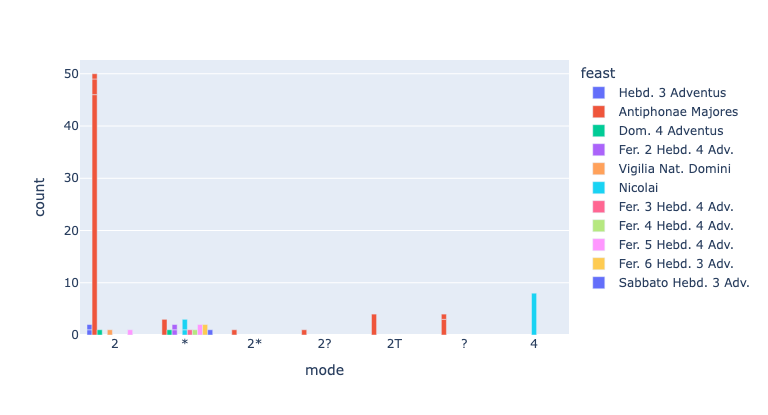

In [14]:
# group by office and mode to see how many chants of each mode are in each office
chant_office_mode_groups = chants_df_clean.groupby(['office_name', 'feast','mode']).size()

fig = px.bar(
    chant_office_mode_groups.reset_index(name='count'),
    x='mode',
    y='count',
    color='feast',
    width=800,
    height=400,)
fig.show()


### 4h.Exploring Feasts and Chant Titles

The `incipit` is the opening phrase of the chant text — effectively its title.  
The `feast` field gives the liturgical occasion.

In [15]:
# Most common feast names
feast_counts = chants_df_clean['feast'].value_counts().head(15)
print("Top 15 feasts:")
print(feast_counts)

Top 15 feasts:
feast
Antiphonae Majores      70
Nicolai                 12
Vigilia Nat. Domini      3
Fer. 5 Hebd. 4 Adv.      3
Hebd. 3 Adventus         2
Fer. 2 Hebd. 4 Adv.      2
Dom. 4 Adventus          2
Fer. 6 Hebd. 3 Adv.      2
Pro paenitentibus        1
Sabbato Hebd. 3 Adv.     1
Fer. 3 Hebd. 4 Adv.      1
Fer. 4 Hebd. 4 Adv.      1
Name: count, dtype: int64


### 4i. Filter for a Particular Feast

In [16]:
# Show chant titles (incipits) for a specific feast
# Change this to any feast name you see above
SELECTED_FEAST = 'Nicolai'

our_feast_chants = chants_df_clean[chants_df_clean['feast'] == SELECTED_FEAST]
our_feast_chants


,cantus_id,incipit,siglum,srclink,chantlink,feast,genre,office,mode,melody_id,melody,century,full_text,rite,_has_melody,melody_object,genre_name,office_name
0,004141,Omnibus se invocantibus benignus adest,A-Gu 29,https://cantusdatabase.org/source/123610,https://cantusdatabase.org/chant/245439,Nicolai,A,M,4,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None,Antiphon,Matins
1,004141,Omnibus se*,A-Gu 29,https://cantusdatabase.org/source/123610,https://cantusdatabase.org/chant/245471,Nicolai,A,N,*,None,None,None,Omnibus se*,Franco-Roman,False,None,Antiphon,None
2,004141,Omnibus se invocantibus benignus adest,A-Gu 30,https://cantusdatabase.org/source/123611,https://cantusdatabase.org/chant/252176,Nicolai,A,M,4,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None,Antiphon,Matins
3,004141,Omnibus se invocantibus*,A-Gu 30,https://cantusdatabase.org/source/123611,https://cantusdatabase.org/chant/252212,Nicolai,A,N,*,None,None,None,Omnibus se invocantibus*,Franco-Roman,False,None,Antiphon,None
4,004141,Omnibus se invocantibus,A-LIb 290,https://cantusdatabase.org/source/123617,https://cantusdatabase.org/chant/338637,Nicolai,A,M,*,None,None,None,None,Franco-Roman,False,None,Antiphon,Matins
5,004141,Omnibus se invocantibus benignus adest,A-Wn Cod. 1890,https://cantusdatabase.org/source/123713,https://cantusdatabase.org/chant/548683,Nicolai,A,M,4,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None,Antiphon,Matins
6,004141,Omnibus se invocantibus benignus adest,CH-E 611,https://cantusdatabase.org/source/123606,https://cantusdatabase.org/chant/231265,Nicolai,A,M,4,None,1---fE--de--fdc---dc---d--ef--g--de--e---dh--h...,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,True,1---fE--de--fdc---dc---d--ef--g--de--e---dh--h...,Antiphon,Matins
7,004141,Omnibus se invocantibus benignus adest sanctus,CZ-Pu (Praha) XIV C 20,https://cantusbohemiae.cz/source/9137,https://cantusbohemiae.cz/chant/28023,Nicolai,A,M,4,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None,Antiphon,Matins
8,004141,Omnibus se invocantibus,CZ-Pu VI.E.4c,https://cantusdatabase.org/source/123727,https://cantusdatabase.org/chant/461832,Nicolai,A,M,None,None,None,None,Omnibus se invocantibus benignus adest sanctus...,Franco-Roman,False,None,Antiphon,Matins
9,004141,Omnibus se invocantibus,CZ-Pu XIV B 13,https://cantusdatabase.org/source/123730,https://cantusdatabase.org/chant/467788,Nicolai,A,M,4,None,None,None,None,Franco-Roman,False,None,Antiphon,Matins


### Key Fields on Each `Chant` Object

| Field | Example | Notes |
|:---|:---|:---|
| `cantus_id` | `'007282'` | links to cantusdatabase.org/id/ |
| `incipit` | `'Ecce nomen Domini'` | opening words |
| `siglum` | `'CH-SGs 390'` | manuscript abbreviation |
| `folio` | `'006r'` | |
| `feast` | `'Dom. Adventus'` | |
| `office` | `'M'` | Matins, Lauds, etc. |
| `genre` | `'A'` | A=Antiphon, R=Responsory, etc. |
| `mode` | `'1'` | |
| `melody` | volpiano string | present on melodic chants only |
| `chantlink` | URL | direct link to chant record |


## 5.  Melodies!

Our first task is to identify which chants have melodies.  Not all chant records have melodies — some are just text.  We can use the `melody` field to find out which ones do.

Filter the df with a conditional statement to find chants that have a melody (i.e. where the `melody` field is not empty).  


In [17]:
# filtering for chants with melodies 
melody_chants = chants_df[chants_df['_has_melody'] == True]
melody_chants.head()

,locked,cantus_id,incipit,siglum,srclink,chantlink,folio,db,feast,genre,...,position,mode,melody_id,melody,century,full_text,image,rite,_has_melody,melody_object
6,True,004141,Omnibus se invocantibus benignus adest,CH-E 611,https://cantusdatabase.org/source/123606,https://cantusdatabase.org/chant/231265,157v,CD,Nicolai,A,...,2.6,4,None,1---fE--de--fdc---dc---d--ef--g--de--e---dh--h...,None,Omnibus se invocantibus benignus adest sanctus...,http://www.e-codices.unifr.ch/en/sbe/0611/157v...,Franco-Roman,True,1---fE--de--fdc---dc---d--ef--g--de--e---dh--h...
10,True,004141,Omnibus se invocantibus benignus adest,D-KA Aug. LX,https://cantusdatabase.org/source/123612,https://cantusdatabase.org/chant/614844,004r,CD,Nicolai,A,...,2.6,4,None,1---fE--de--fdc---dc---d--f7--g--de--e---dh--h...,None,Omnibus se invocantibus benignus adest sanctus...,http://digital.blb-karlsruhe.de/blbhs/content/...,Franco-Roman,True,1---fE--de--fdc---dc---d--f7--g--de--e---dh--h...
23,True,004025,O Emmanuel rex et legifer,A-Wn 1799**,https://cantusdatabase.org/source/123667,https://cantusdatabase.org/chant/543451,015v,CD,Antiphonae Majores,A,...,7M,2T,None,1---hk-kj---kh--jh--gh--h---j---h---h--jk--hj-...,None,O Emmanuel rex et legifer noster exspectatio g...,http://digital.onb.ac.at/RepViewer/viewer.face...,Franco-Roman,True,1---hk-kj---kh--jh--gh--h---j---h---h--jk--hj-...
28,True,004025,O Emmanuel rex et legifer,CDN-Hsmu M2149.L4,https://cantusdatabase.org/source/123723,https://cantusdatabase.org/chant/270424,029r,CD,Antiphonae Majores,A,...,7M,2,None,1---df-fe---fd--ed--cd--d---e---d---ef--d--de-...,None,O Emmanuel rex et legifer noster exspectatio g...,https://cantus.simssa.ca/manuscript/123723/?fo...,Franco-Roman,True,1---df-fe---fd--ed--cd--d---e---d---ef--d--de-...
29,True,004025,O Emmanuel rex et legifer,CH-E 611,https://cantusdatabase.org/source/123606,https://cantusdatabase.org/chant/228598,015r,CD,Antiphonae Majores,A,...,7M,2,None,1---dfe---fd--fd--cd--d---f---d---d--ef--dfE--...,None,O Emmanuel rex et legifer noster exspectatio g...,http://www.e-codices.unifr.ch/en/sbe/0611/15r/...,Franco-Roman,True,1---dfe---fd--fd--cd--d---f---d---d--ef--dfE--...


In [18]:
# Each chant with a melody has a `melody_object` field that contains a `Melody` object with all the details about the melody.  Let's look at the first one:

our_melody_object = melody_chants.iloc[0]['melody_object']
vars(our_melody_object)

{'locked': False,
 'raw_volpiano': '1---fE--de--fdc---dc---d--ef--g--de--e---dh--hG--g---hk--hg-gfe---e--g---gh--hgfe--de--e77---efg--fe--d---g--f---gh--gfe--dE---e--e---4---h--g--h--k--g--e---3',
 'volpiano': '1---fE--de--fdc---dc---d--ef--g--de--e---dh--hG--g---hk--hg-gfe---e--g---gh--hgfe--de--e77---efg--fe--d---g--f---gh--gfe--dE---e--e---4---h--g--h--k--g--e---3',
 'mode': '4',
 'chantlink': 'https://cantusdatabase.org/chant/231265',
 'cantus_id': '004141'}

In [19]:
# just the volpiano string from that object:
our_melody_object.volpiano

'1---fE--de--fdc---dc---d--ef--g--de--e---dh--hG--g---hk--hg-gfe---e--g---gh--hgfe--de--e77---efg--fe--d---g--f---gh--gfe--dE---e--e---4---h--g--h--k--g--e---3'

### 5a. Melody Methods

The `Melody` object attached to a chant (`chant.melody_object`) exposes these methods for cleaning and analyzing the Volpiano string. All methods except `get_range` **mutate `melody.volpiano` in place**.

| Method | Code to use it |
|:---|:---|
| `clean_volpiano` — keep only allowed pitch characters | `melody.clean_volpiano()` |
| `normalize_volpiano` — remove differentiae, normalize liquescents, and clean | `melody.normalize_volpiano()` |
| `expand_accidentals` — propagate accidentals to all affected notes in scope | `melody.expand_accidentals()` |
| `normalize_liquescents` — treat liquescences as ordinary notes | `melody.normalize_liquescents()` |
| `discard_differentia` — strip trailing differentia if present | `melody.discard_differentia()` |
| `get_range` — steps below/above final note (**requires fully cleaned string**: call `normalize_volpiano()` first) | `melody.normalize_volpiano(); below, above = melody.get_range()` |

In [20]:


# Get a chant with a melody
chant_with_melody = next(c for c in corpus.chants if c._has_melody)
mel = chant_with_melody.melody_object

print("raw:                  ", mel.volpiano[:60])

# Each method mutates melody.volpiano in place — copy first to preserve the original
m = copy.copy(mel); m.clean_volpiano()
print("clean_volpiano:       ", m.volpiano[:60])

m = copy.copy(mel); m.normalize_volpiano()
print("normalize_volpiano:   ", m.volpiano[:60])

m = copy.copy(mel); m.expand_accidentals()
print("expand_accidentals:   ", m.volpiano[:60])

m = copy.copy(mel); m.normalize_liquescents()
print("normalize_liquescents:", m.volpiano[:60])

m = copy.copy(mel); m.discard_differentia()
print("discard_differentia:  ", m.volpiano[:60])

# get_range requires a fully cleaned string (no barlines, clef chars, boundaries)
m = copy.copy(mel); m.normalize_volpiano()
print("get_range():          ", m.get_range())

raw:                   1---fE--de--fdc---dc---d--ef--g--de--e---dh--hG--g---hk--hg-
clean_volpiano:        fEdefdcdcdefgdeedhhGghkhggfeegghhgfedeeefgfedgfghgfedEeehghk
normalize_volpiano:    fedefdcdcdefgdeedhhgghkhggfeegghhgfedeeefgfedgfghgfedeee
expand_accidentals:    1---fE--de--fdc---dc---d--ef--g--de--e---dh--hG--g---hk--hg-
normalize_liquescents: 1---fe--de--fdc---dc---d--ef--g--de--e---dh--hg--g---hk--hg-
discard_differentia:   1---fE--de--fdc---dc---d--ef--g--de--e---dh--hG--g---hk--hg-
get_range():           (-2, 5)


There are many other details about the Volpiano encoding that we can explore with these methods, but this is a good starting point for cleaning and analyzing the melodies in our dataset.

5b.  Render with Verovio

Verovio is a powerful library for rendering music notation, and it can take a Volpiano string as input.  We can use the `renderData` function from the `verovio` module to render the melody as SVG.  This allows us to visualize the chant melodies directly in our notebook.

[Warning] Justification is highly compressed (ratio smaller than 0.8: 0.656571)
[Warning] 	System full width: 21000
[Warning] 	Non-justifiable width: 645
[Warning] 	Drawing justifiable width: 31002


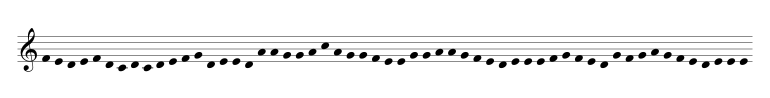

In [21]:


tk = verovio.toolkit()

# normalize first so Verovio gets clean pitch characters
m = copy.copy(mel)
m.normalize_volpiano()

svg = tk.renderData(m.volpiano, {
    "inputFrom": "volpiano",
    "scale": 35,
    "pageWidth": 2200,
    "adjustPageHeight": True,
})
display(SVG(svg))
